In [1]:
# Import libraries
import pandas as pd
import numpy as np
from ctgan import CTGAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
#from tensorflow_privacy.privacy.optimizers.dp_optimizer_keras import DPKerasSGDOptimizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC
import tensorflow as tf


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
# Load Dataset
df = pd.read_csv("SAML-D.csv")

# Initial Data Exploration
df.head()
df.describe()

# Drop columns that are not useful
columns_to_drop = ["Laundering_type", "Time", "Date"]
df.drop(columns=columns_to_drop, inplace=True)

# Handle missing data
df.dropna(inplace=True)

# Encode categorical features
categorical_cols = ["Sender_account", "Receiver_account", "Payment_currency", "Received_currency", "Sender_bank_location", "Receiver_bank_location", "Payment_type"]
label_encoders = {}
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

# Address skewness in 'Amount'
df['Amount'] = np.log1p(df['Amount'])

# Split independent (X) and target (y) variables
X = df.drop(columns=["Is_laundering"])
y = df["Is_laundering"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)


In [3]:
df

,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering
0,255277,180462,7.286294,10,10,16,16,1,0
1,43554,548141,8.702949,10,1,16,15,5,0
2,8553,287765,9.570071,10,10,16,16,3,0
3,157249,626370,9.383957,10,10,16,16,0,0
4,281324,248338,4.755743,10,10,16,16,1,0
...,...,...,...,...,...,...,...,...,...
9504847,71859,33846,7.717907,10,10,16,16,0,0
9504848,287042,353757,6.833226,10,10,16,16,6,0
9504849,213308,195423,7.283544,10,10,16,16,0,0
9504850,27570,314503,10.165725,10,10,16,16,0,0


C:\Users\dhari\AppData\Local\Temp\ipykernel_26496\3574181449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Is_laundering', palette='viridis')


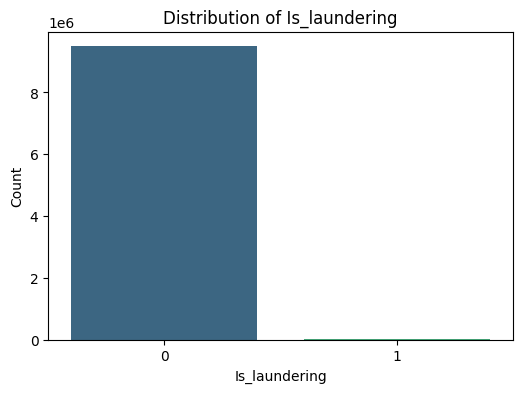

Is_laundering
0    99.896127
1     0.103873
Name: proportion, dtype: float64


In [165]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Is_laundering', palette='viridis')
plt.title("Distribution of Is_laundering")
plt.xlabel("Is_laundering")
plt.ylabel("Count")
plt.show()

# Percentage of each class
print(df['Is_laundering'].value_counts(normalize=True) * 100)


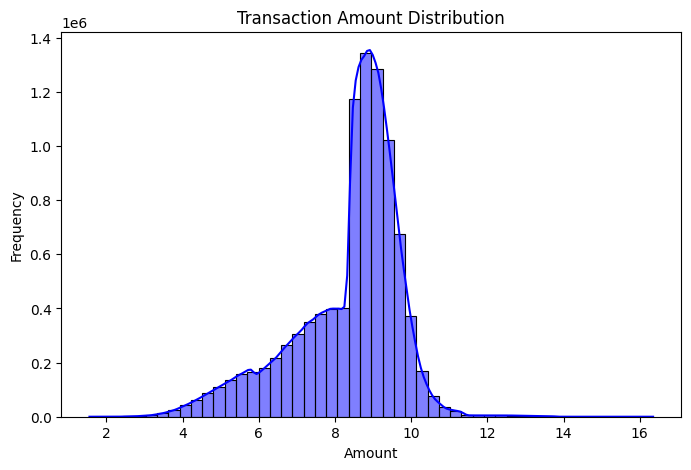

In [166]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


C:\Users\dhari\AppData\Local\Temp\ipykernel_26496\1946539894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_laundering', y='Amount', palette='muted')


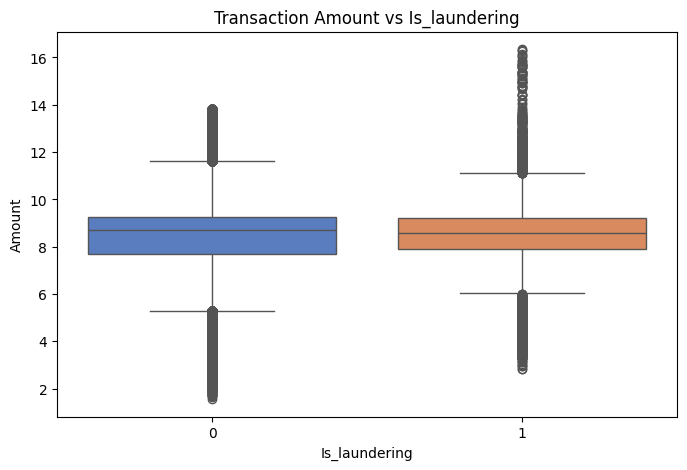

In [167]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Is_laundering', y='Amount', palette='muted')
plt.title("Transaction Amount vs Is_laundering")
plt.xlabel("Is_laundering")
plt.ylabel("Amount")
plt.show()


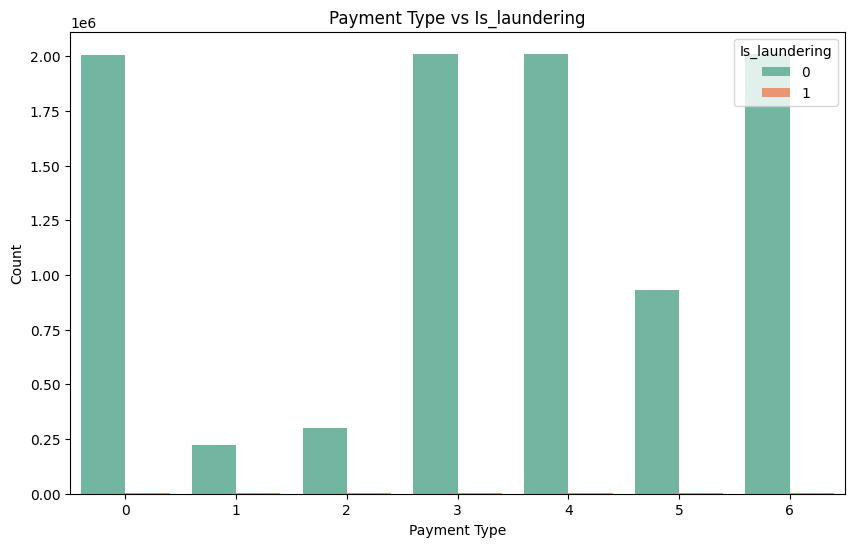

In [168]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Payment_type', hue='Is_laundering', palette='Set2')
plt.title("Payment Type vs Is_laundering")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.legend(title="Is_laundering")
plt.show()


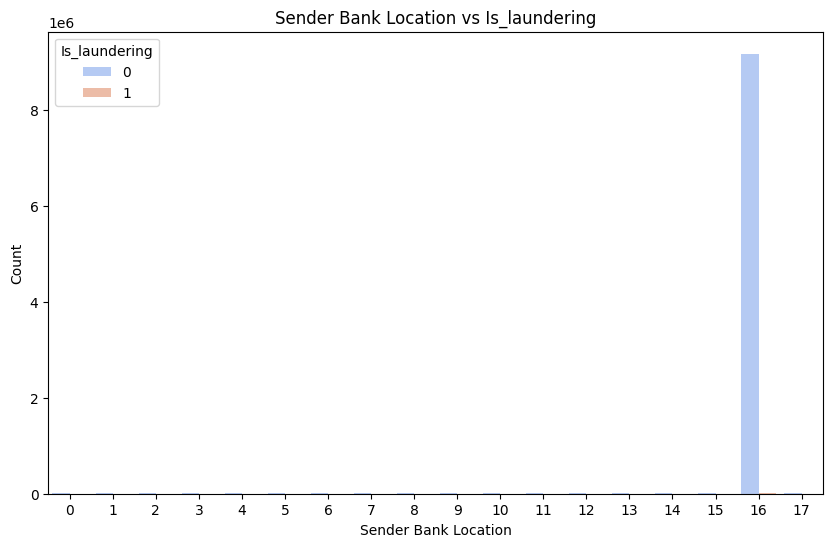

In [169]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sender_bank_location', hue='Is_laundering', palette='coolwarm')
plt.title("Sender Bank Location vs Is_laundering")
plt.xlabel("Sender Bank Location")
plt.ylabel("Count")
plt.legend(title="Is_laundering")
plt.show()


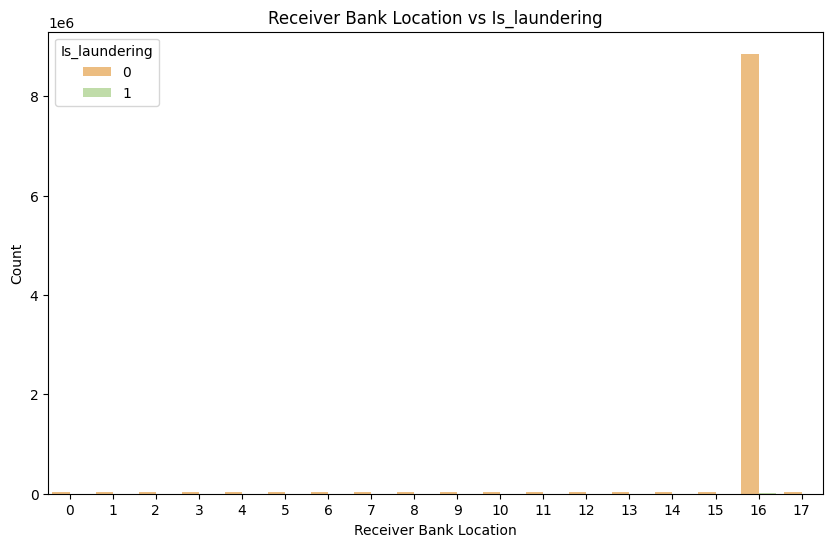

In [170]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Receiver_bank_location', hue='Is_laundering', palette='Spectral')
plt.title("Receiver Bank Location vs Is_laundering")
plt.xlabel("Receiver Bank Location")
plt.ylabel("Count")
plt.legend(title="Is_laundering")
plt.show()


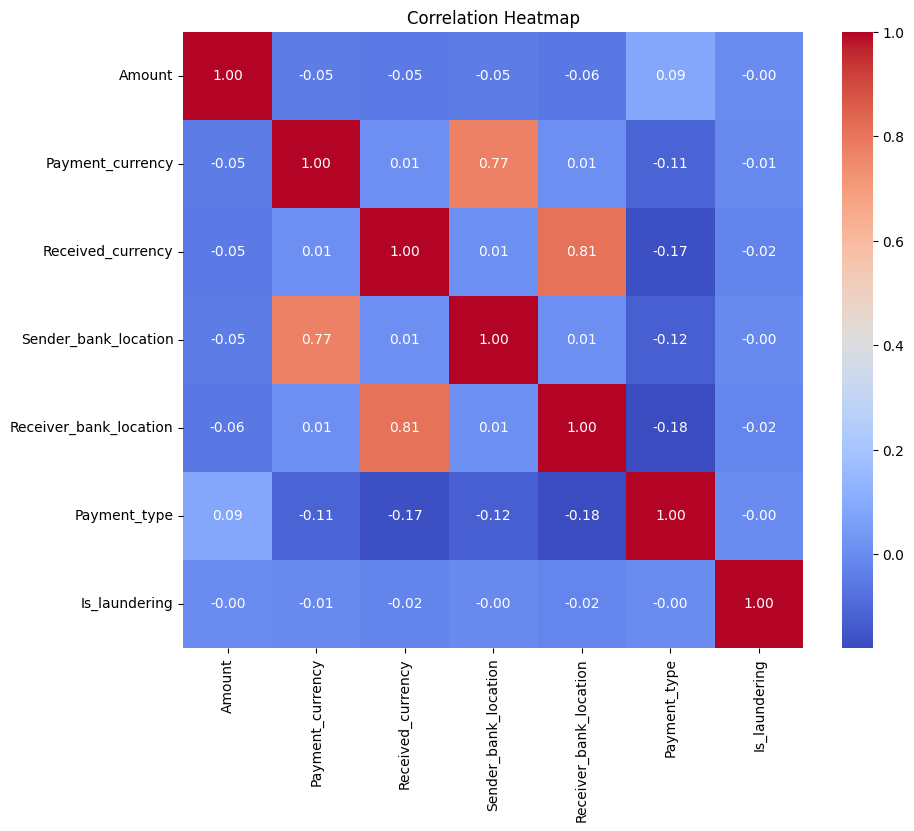

In [171]:
plt.figure(figsize=(10, 8))
correlation = df[['Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


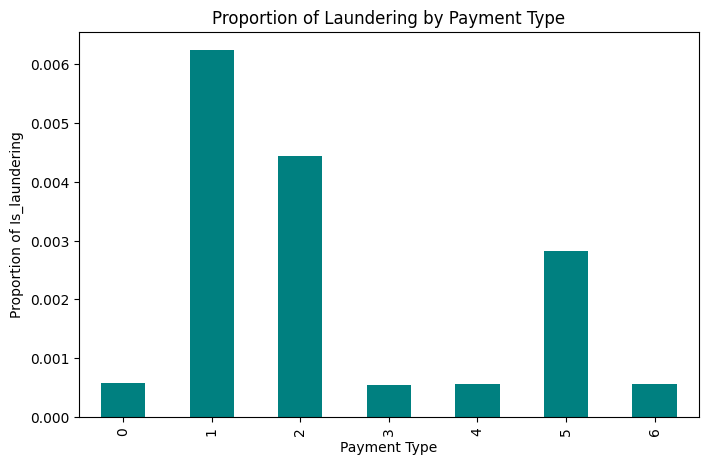

In [4]:
laundering_by_payment = df.groupby('Payment_type')['Is_laundering'].mean()
laundering_by_payment.plot(kind='bar', figsize=(8, 5), color='teal')
plt.title("Proportion of Laundering by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Proportion of Is_laundering")
plt.show()


In [5]:
df.nunique()

Sender_account             292715
Receiver_account           652266
Amount                    2314277
Payment_currency               13
Received_currency              13
Sender_bank_location           18
Receiver_bank_location         18
Payment_type                    7
Is_laundering                   2
dtype: int64

In [6]:
df["Is_laundering"].value_counts()

Is_laundering
0    9494979
1       9873
Name: count, dtype: int64

In [7]:
laundering=df[df["Is_laundering"]==1]
non_laundering=df[df["Is_laundering"]==0].sample(n=60000,replace=False,random_state=4)
new_df=pd.concat([laundering,non_laundering])

In [9]:
import torch
from ctgan import CTGAN

# Ensure GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Training CTGAN
print("Training CTGAN to generate synthetic data...")
gan = CTGAN(epochs=100)
gan.device = device  # Set device for CTGAN
gan.fit(
    new_df[new_df["Is_laundering"]==1],
    discrete_columns=[
        'Payment_currency',
        'Received_currency',
        'Sender_bank_location',
        'Receiver_bank_location',
        'Payment_type'
    ]
)

Using device: cpu
Training CTGAN to generate synthetic data...


In [16]:
synthetic_data = gan.sample(10000)
df1=pd.concat([new_df,synthetic_data])

# Split independent (X) and target (y) variables
X = df1.drop(columns=["Is_laundering"])
y = df1["Is_laundering"]


C:\Users\dhari\AppData\Local\Temp\ipykernel_46268\1824037202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x='Is_laundering', palette='viridis')


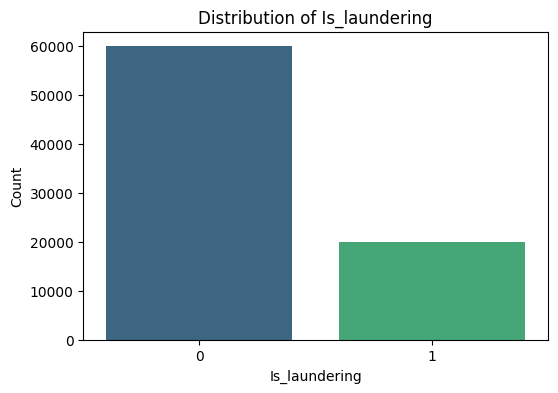

Is_laundering
0    75.119252
1    24.880748
Name: proportion, dtype: float64


In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df1, x='Is_laundering', palette='viridis')
plt.title("Distribution of Is_laundering")
plt.xlabel("Is_laundering")
plt.ylabel("Count")
plt.show()

# Percentage of each class
print(df1['Is_laundering'].value_counts(normalize=True) * 100)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4, stratify=y)


Performance of Regular Logistic Regression:
              precision    recall  f1-score   support

           0       0.78      0.96      0.86     12000
           1       0.60      0.19      0.29      3975

    accuracy                           0.77     15975
   macro avg       0.69      0.58      0.58     15975
weighted avg       0.74      0.77      0.72     15975



c:\Users\dhari\anaconda3\envs\tf-gpu\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


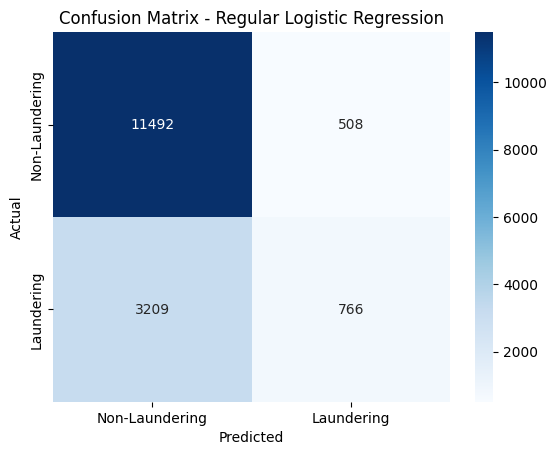

In [20]:
# Define function to evaluate models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\nPerformance of {model_name}:")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Laundering", "Laundering"], yticklabels=["Non-Laundering", "Laundering"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



# Train a regular logistic regression model
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model(y_test, y_pred_lr, "Regular Logistic Regression")




Performance of Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     12000
           1       0.83      0.62      0.71      3975

    accuracy                           0.87     15975
   macro avg       0.86      0.79      0.81     15975
weighted avg       0.87      0.87      0.87     15975



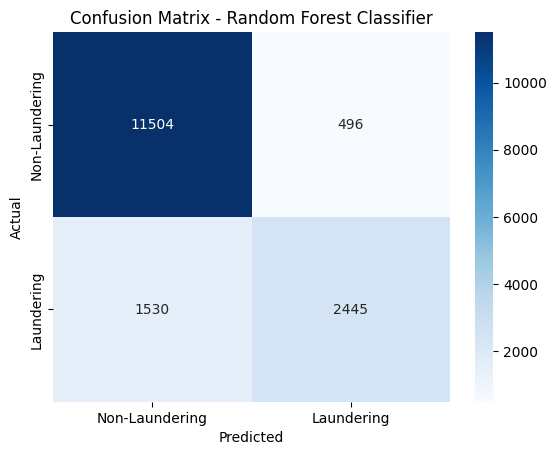

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluate_model(y_test, y_pred, "Random Forest Classifier")

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(lr=0.01), loss='binary_crossentropy', metrics=['accuracy'])

class_weight = {0: 1, 1: len(y_train) / y_train.sum()}
model.fit(X_train, y_train,  epochs=10, batch_size=64)


Epoch 1/10


c:\Users\dhari\anaconda3\envs\tf-gpu\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


999/999 [==============================] - 4s 2ms/step - loss: 273.1692 - accuracy: 0.7029
Epoch 2/10
999/999 [==============================] - 2s 2ms/step - loss: 0.6298 - accuracy: 0.7513
Epoch 3/10
999/999 [==============================] - 2s 2ms/step - loss: 0.5611 - accuracy: 0.7513
Epoch 4/10
999/999 [==============================] - 2s 2ms/step - loss: 0.5611 - accuracy: 0.7513
Epoch 5/10
999/999 [==============================] - 2s 2ms/step - loss: 0.5612 - accuracy: 0.7513
Epoch 6/10
999/999 [==============================] - 3s 3ms/step - loss: 0.5611 - accuracy: 0.7513
Epoch 7/10
999/999 [==============================] - 3s 3ms/step - loss: 0.5613 - accuracy: 0.7513
Epoch 8/10
999/999 [==============================] - 3s 3ms/step - loss: 0.5612 - accuracy: 0.7513
Epoch 9/10
999/999 [==============================] - 3s 3ms/step - loss: 0.5614 - accuracy: 0.7513
Epoch 10/10
999/999 [==============================] - 3s 3ms/step - loss: 0.5613 - accuracy: 0.7513


In [23]:
y_pred = model.predict(X_test)
y_pred

500/500 [==============================] - 1s 1ms/step


array([[0.24603926],
       [0.24603926],
       [0.24603926],
       ...,
       [0.24603926],
       [0.24603926],
       [0.24603926]], dtype=float32)

In [25]:
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(class_weight='balanced')
# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best Parameters:", grid_search.best_params_)

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     12000
           1       0.79      0.65      0.71      3975

    accuracy                           0.87     15975
   macro avg       0.84      0.80      0.81     15975
weighted avg       0.87      0.87      0.87     15975




Performance of Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92     12000
           1       0.79      0.65      0.71      3975

    accuracy                           0.87     15975
   macro avg       0.84      0.80      0.81     15975
weighted avg       0.87      0.87      0.87     15975



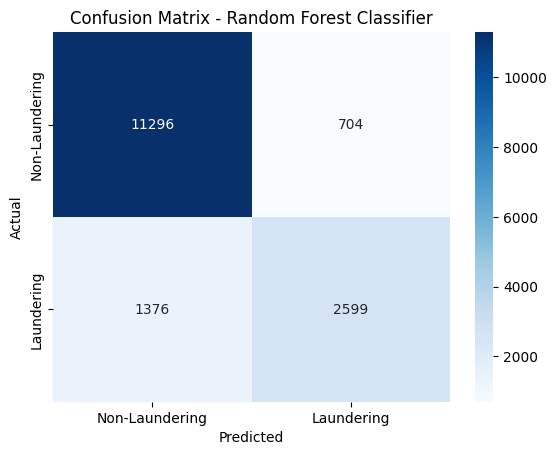

In [26]:
evaluate_model(y_test, y_pred, "Random Forest Classifier")

In [ ]:

# Train a differentially private logistic regression model
print("Training differentially private logistic regression...")
epsilon_values = [0.1, 0.5, 1.0, 5.0]
for epsilon in epsilon_values:
    dp_lr = DPKerasSGDOptimizer(
        l2_norm_clip=1.0,
        noise_multiplier=1.0 / epsilon,
        num_microbatches=1,
        learning_rate=0.01
    )
    model = Sequential([
        Dense(10, activation='relu', input_dim=X_train.shape[1]),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=dp_lr, loss=BinaryCrossentropy(), metrics=[AUC()])
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_dp = (model.predict(X_test) > 0.5).astype(int)
    print(f"\nEpsilon: {epsilon}")
    evaluate_model(y_test, y_pred_dp, f"Differentially Private Logistic Regression (epsilon={epsilon})")


# Visualize privacy-performance trade-off
results = []
for epsilon in epsilon_values:
    dp_lr = DPKerasSGDOptimizer(
        l2_norm_clip=1.0,
        noise_multiplier=1.0 / epsilon,
        num_microbatches=1,
        learning_rate=0.01
    )
    model = Sequential([
        Dense(10, activation='relu', input_dim=X_train.shape[1]),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=dp_lr, loss=BinaryCrossentropy(), metrics=[AUC()])
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_dp = (model.predict(X_test) > 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_dp)
    results.append((epsilon, acc))

plt.figure(figsize=(10, 6))
results = pd.DataFrame(results, columns=["Epsilon", "Accuracy"])
plt.plot(results["Epsilon"], results["Accuracy"], marker='o')
plt.title("Privacy-Performance Trade-off")
plt.xlabel("Epsilon (Privacy)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()